In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import Rbf
from IPython.display import Markdown, display

In [4]:
df = pd.read_excel("../../docs/Database/InterstitialLoop.xlsx")
df["Paper"] = df["Paper"].ffill()
df["Paper_short"] = df["Paper"].apply(lambda x: " - ".join(x.split(" - ")[:2]))
markers = ["o", "s", "^", "*", "D", "P", "X", "v", "<", ">"]

### Fraction of ⟨100⟩ Dislocation-loop Transition Map

In [5]:
df2 = df[["Fraction of <100> [%]", "Irradiation Temp [C]", "Dose [dpa]", "Paper_short", "Type of Irradiation", ]].copy()
df2 = df2.dropna().reset_index(drop=True)
paper_list = df2["Paper_short"].unique()
marker_map = {
    paper: markers[i % len(markers)]
    for i, paper in enumerate(paper_list)
}

df_clean = (df2.drop_duplicates().reset_index(drop=True))

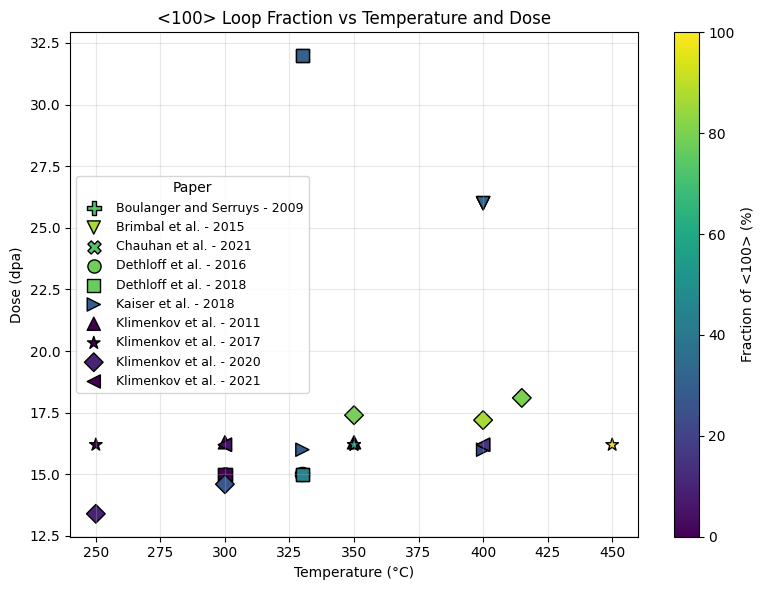

In [6]:
plt.figure(figsize=(8, 6))
for paper, sub in df_clean.groupby("Paper_short"):
    plt.scatter(
        sub["Irradiation Temp [C]"],
        sub["Dose [dpa]"],
        c=sub["Fraction of <100> [%]"],
        cmap="viridis",
        vmin=df_clean["Fraction of <100> [%]"].min(),
        vmax=df_clean["Fraction of <100> [%]"].max(),
        marker=marker_map[paper],
        s=90,
        edgecolors="k",
        label=paper,
    )

cbar = plt.colorbar()
cbar.set_label("Fraction of <100> (%)")

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("<100> Loop Fraction vs Temperature and Dose")

plt.legend(title="Paper", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

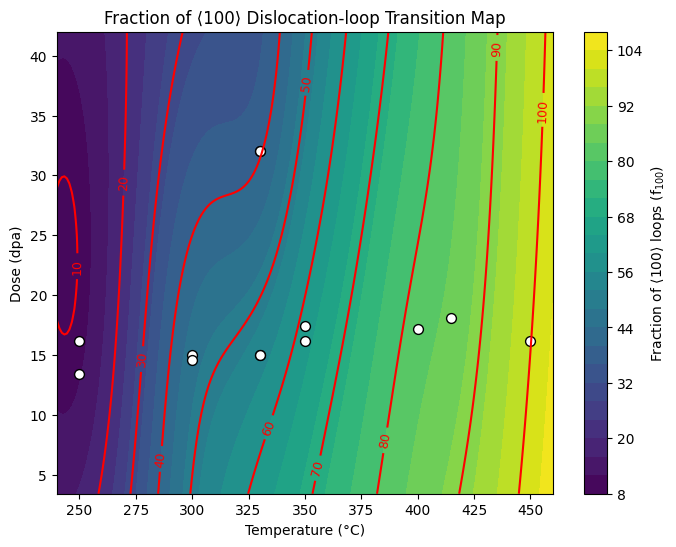

In [7]:
points = [(300,15,77), (330,15,72), (330,15,45),(330,32,27),(330,32,31),(250,16.2,0),(350,16.2,50),(450,16.2,100),(250,13.4,10),(300,14.6,27),(350,17.4,79),(400,17.2,87),(415,18.1,80)]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-10, max(T)+10, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=30)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 100, 11), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Fraction of ⟨100⟩ loops ($f_{100}$)')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('Fraction of ⟨100⟩ Dislocation-loop Transition Map')
plt.show()

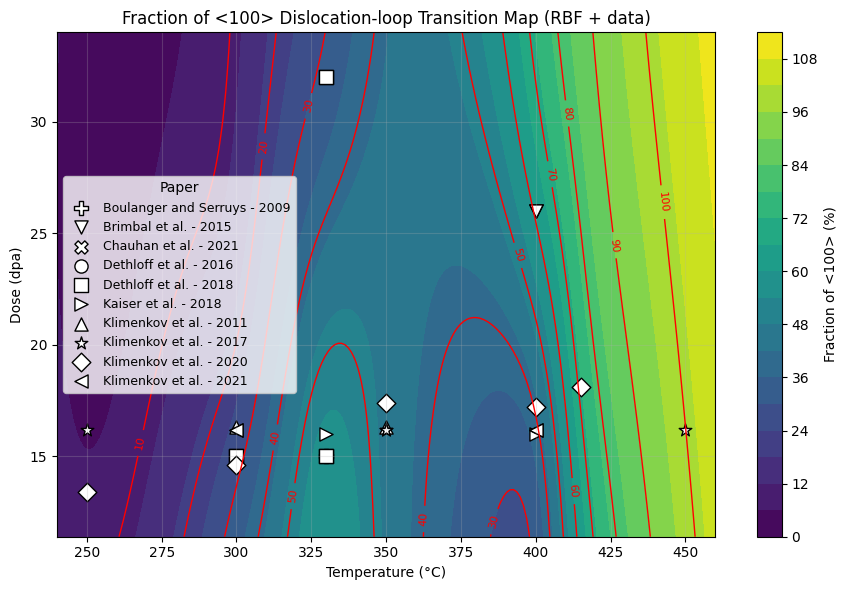

In [8]:
# data
T = df_clean["Irradiation Temp [C]"].to_numpy()
D = df_clean["Dose [dpa]"].to_numpy()
F = df_clean["Fraction of <100> [%]"].to_numpy()

# RBF fit
rbf = Rbf(T, D, F, function="multiquadric", smooth=0.5)  # tune smooth

# grid
Ti = np.linspace(min(T)-10, max(T)+10, 200)
Di = np.linspace(min(D)-2, max(D)+2, 200)
TT, DD = np.meshgrid(Ti, Di)
FF = rbf(TT, DD)

# marker map (same as before)
markers = ["o","s","^","*","D","P","X","v","<",">"]
paper_list = df_clean["Paper_short"].unique()
marker_map = {p: markers[i % len(markers)] for i, p in enumerate(paper_list)}

plt.figure(figsize=(9, 6))

# ---- background: filled contour from RBF ----
cf = plt.contourf(TT, DD, FF, levels=20, cmap="viridis")
cbar = plt.colorbar(cf)
cbar.set_label("Fraction of <100> (%)")

# optional: red contour lines with labels
cs = plt.contour(TT, DD, FF, levels=np.arange(0, 101, 10), colors="red", linewidths=1)
plt.clabel(cs, fmt="%d", fontsize=8)

for paper, sub in df_clean.groupby("Paper_short"):
    plt.scatter(
        sub["Irradiation Temp [C]"], sub["Dose [dpa]"], marker=marker_map[paper], s=90, facecolors="white", edgecolors="black", label=paper,
    )

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title("Fraction of <100> Dislocation-loop Transition Map (RBF + data)")
plt.grid(alpha=0.25)

plt.legend(title="Paper", fontsize=9, loc="best")
plt.tight_layout()
plt.show()


### ⟨100⟩ Dislocation loop density Transition Map

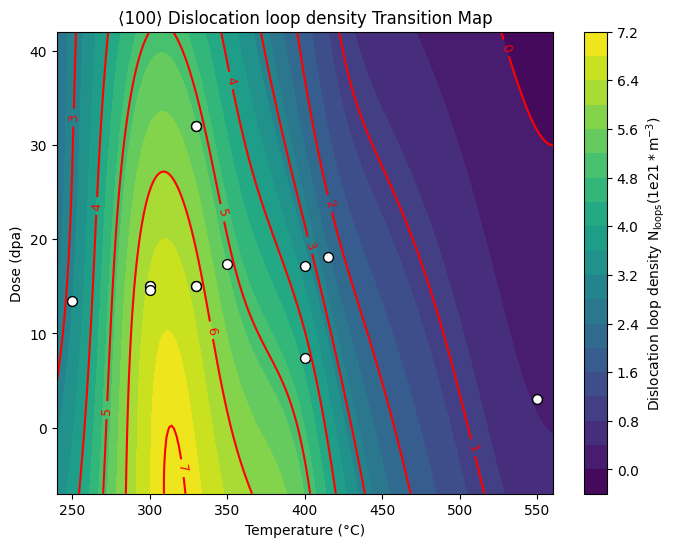

In [9]:
points = [(300,15,4.9e21),(300,15,4.7e21),(330,15,4.97e21),(330,15,9e21),(330,32,2.24e21),(330,32,7.44e21),(250,13.4,1.5e21),(300,14.6,1.2e22),(350,17.4,3.72e21),(400,17.2,2.25e20),(415,18.1,7e19),(550,3,1e20),(400,7.4,1e22)]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2]/1e21 for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-10, max(T)+10, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 10, 11), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Dislocation loop density $N_{loops} (1e21 * m^{-3})$')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('⟨100⟩ Dislocation loop density Transition Map')
plt.show()

### 1/2⟨111⟩ Dislocation loop density Transition Map

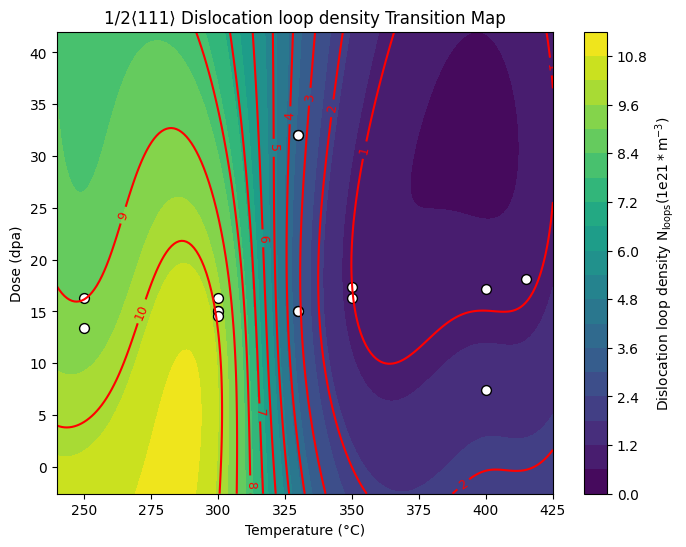

In [10]:
points = [(300,15,1.4e21),(300,15,4e21),(330,15,1.93e21),(330,15,1.1e21),(330,32,6.06e21),(330,32,1.66e21),(250,16.3,2e21),(300,16.3,4e21),(350,16.3,3e20),(250,13.4,1.5e22),(300,14.6,3.4e22),(350,17.4,9.5e20),(400,17.2,2.5e19),(415,18.1,1e19),(400,7.4,3e21)]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2]/1e21 for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-10, max(T)+10, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 10, 11), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Dislocation loop density $N_{loops} (1e21 * m^{-3})$')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('1/2⟨111⟩ Dislocation loop density Transition Map')
plt.show()

### ⟨100⟩ Dislocation loop diameter Transition Map

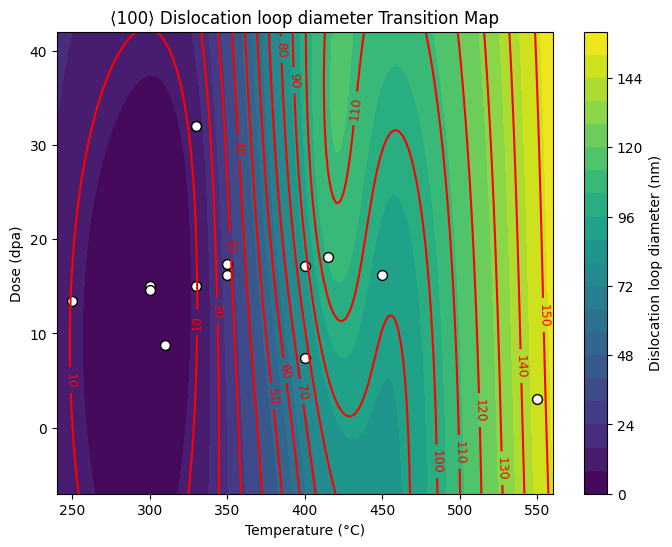

In [11]:
points = [(300,15,2.8),(300,15,3.3),(330,15,6.1),(330,15,3.4),(330,32,5.1),(330,32,4.8),(350,16.2,15),(450,16.2,60),(250,13.4,5),(300,14.6,8),(350,17.4,48),(400,17.2,110),(415,18.1,180),(550,3,150),(310,8.8,5.4),(400,7.4,14)]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-10, max(T)+10, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 150, 16), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Dislocation loop diameter (nm)')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('⟨100⟩ Dislocation loop diameter Transition Map')
plt.show()

### 1/2⟨111⟩ Dislocation loop diameter Transition Map

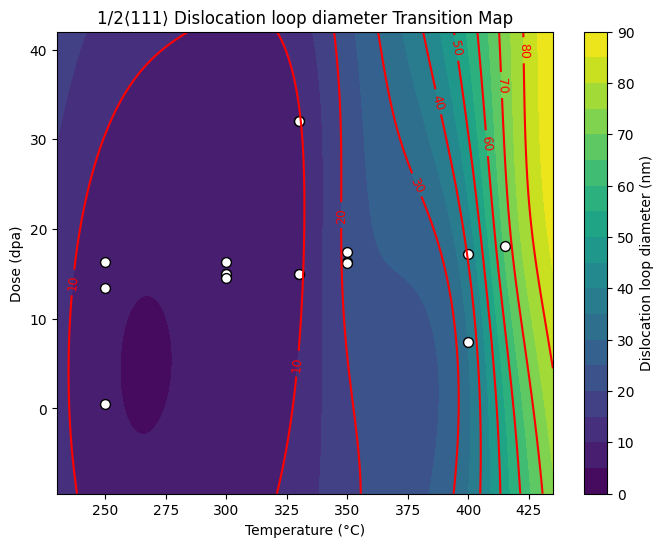

In [12]:
points = [(300,15,4.2),(300,15,3.3),(330,15,6.1),(330,15,3.4),(330,32,5.1),(330,32,4.9),(250,16.3,7),(300,16.3,14),(350,16.3,35),(350,16.2,26),(250,13.4,5),(300,14.6,6),(350,17.4,20),(400,17.2,25),(415,18.1,100),(250,0.5,2.4),(400,7.4,10)]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-20, max(T)+20, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 150, 16), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Dislocation loop diameter (nm)')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('1/2⟨111⟩ Dislocation loop diameter Transition Map')
plt.show()

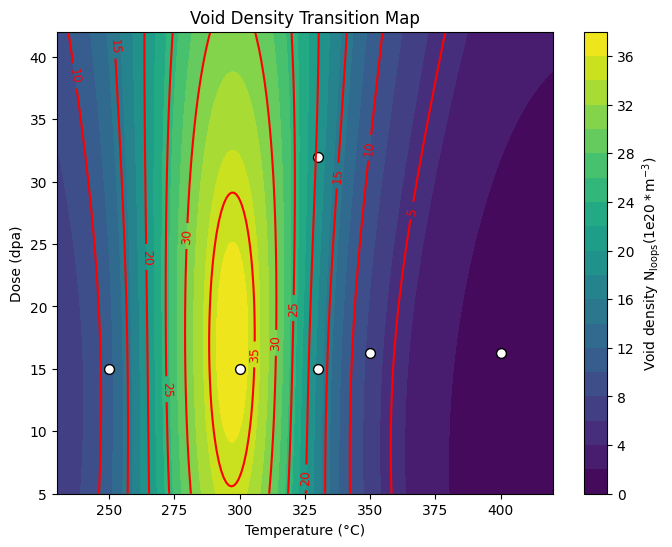

In [13]:
points = [(250, 15, 0),(300, 15, 63),(350, 16.3, 3.20),(400, 16.3, 0.03),(330, 15, 3.50),(330, 32, 23)]
T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-20, max(T)+20, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 50, 11), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Void density $N_{loops} (1e20 * m^{-3})$')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('Void Density Transition Map')
plt.show()

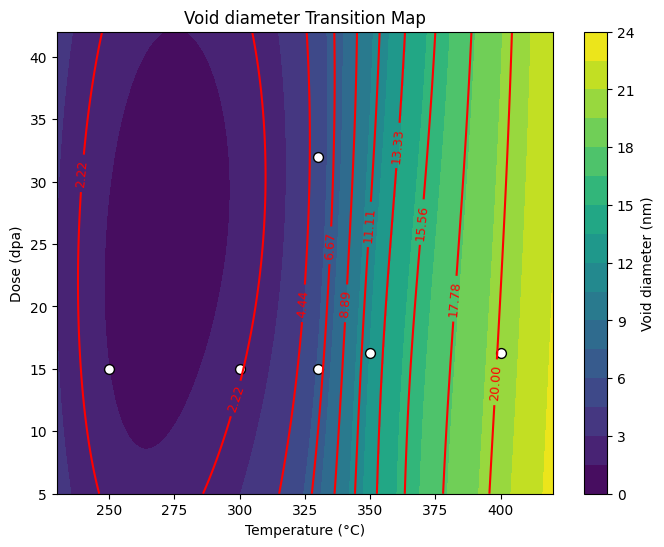

In [14]:
points = [(250, 15, 0),(300, 15, 2.3),(350, 16.3, 18),(400, 16.3, 20),(330, 15, 2.6),(330, 32, 1.6),]

T = np.array([p[0] for p in points])
D = np.array([p[1] for p in points])
Z = np.array([p[2] for p in points])

rbf = Rbf(T, D, Z, function='multiquadric', smooth=1)

Ti = np.linspace(min(T)-20, max(T)+20, 200)
Di = np.linspace(min(D)-10, max(D)+10, 200)
TT, DD = np.meshgrid(Ti, Di)
Zi = rbf(TT, DD)

plt.figure(figsize=(8,6))
contour = plt.contourf(TT, DD, Zi, levels=20)
CS = plt.contour(TT, DD, Zi, levels=np.linspace(0, 20, 10), colors='red', linewidths=1.5)
plt.clabel(CS, colors='red', fontsize=9, inline=True)
plt.colorbar(contour, label='Void diameter (nm)')
plt.scatter(T, D, s=50, color='white', edgecolors='black', label='data points')

plt.xlabel("Temperature (°C)")
plt.ylabel("Dose (dpa)")
plt.title('Void diameter Transition Map')
plt.show()
